In [26]:
import pandas as pd
import numpy as np

In [27]:
dataset_path = "iris.csv"

df = pd.read_csv(dataset_path, header=None, names=['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width', 'Species'])

X = df.iloc[:, :2].values
ones = np.ones((X.shape[0], 1))
X_b = np.hstack((ones, X))

x1 = df.iloc[:, 0].values
x2 = df.iloc[:, 1].values

Y = df.iloc[:, 3].values
Y = Y.reshape(-1, 1)

In [28]:
import numpy as np
W = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ Y

W1 = np.linalg.pinv(X_b) @ Y

In [29]:
def predict(x):
    global W
    return (np.array([x]).dot(W))

In [30]:
predicted_y = list()

for x in X_b:
    predicted_y.append(predict(x))

In [31]:
import matplotlib.pyplot as plt

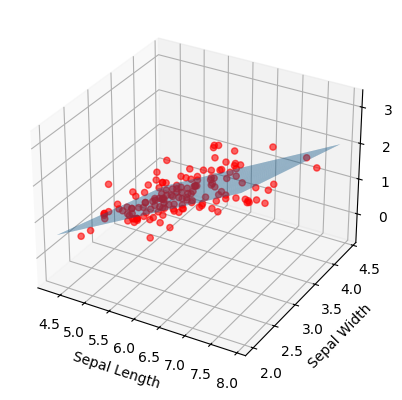

In [44]:
x1_range = np.linspace(x1.min(), x1.max(), 100)
x2_range = np.linspace(x2.min(), x2.max(), 100)

x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

y_prediction_grid = W[0] + W[1]*x1_grid + W[2]*x2_grid

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(x1_grid, x2_grid, y_prediction_grid, alpha=0.5)
ax.scatter(x1, x2, Y.flatten(), color="red", alpha=0.6)
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Width")
plt.show()